In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



In [14]:
# Load your CSV
csv_file = r"metrics_summary.csv"  # path to your CSV
df = pd.read_csv(csv_file)



In [15]:
# --- 1. Quick look at best networks by F1 per adapt ---
best_by_f1 = df.loc[df.groupby('adapt')['f1'].idxmax()]
print("Best networks per adapt (by F1):")
print(best_by_f1[['adapt', 'network', 'dataset', 'f1', 'precision', 'recall']])



Best networks per adapt (by F1):
    adapt  network                                      dataset        f1  \
7       0  iiss_4b  Calb01uLED_hippo_2023-01-12_10-19-17_1558um  0.481958   
23     20  iiss_6b  Calb01uLED_hippo_2023-01-12_10-19-17_1558um  0.028523   
35     60  iiss_6b  Calb01uLED_hippo_2023-01-12_10-19-17_1558um  0.013895   
47    120  iiss_6b  Calb01uLED_hippo_2023-01-12_10-19-17_1558um  0.013895   

    precision    recall  
7    0.424748  0.556978  
23   0.871795  0.014499  
35   0.680000  0.007019  
47   0.680000  0.007019  


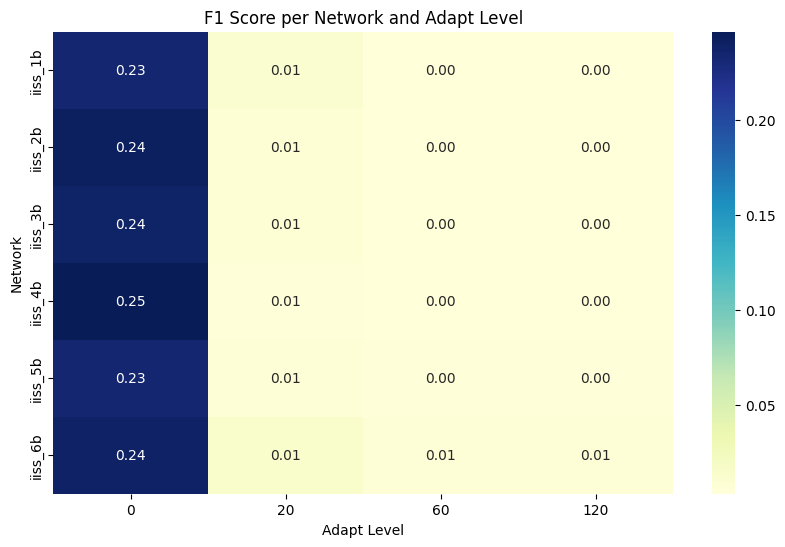

In [16]:
# --- 2. Heatmap of metrics for all networks ---
metrics = ['precision', 'recall', 'accuracy', 'f1']
pivot = df.pivot_table(index='network', columns='adapt', values='f1')  # F1 heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("F1 Score per Network and Adapt Level")
plt.ylabel("Network")
plt.xlabel("Adapt Level")
plt.show()



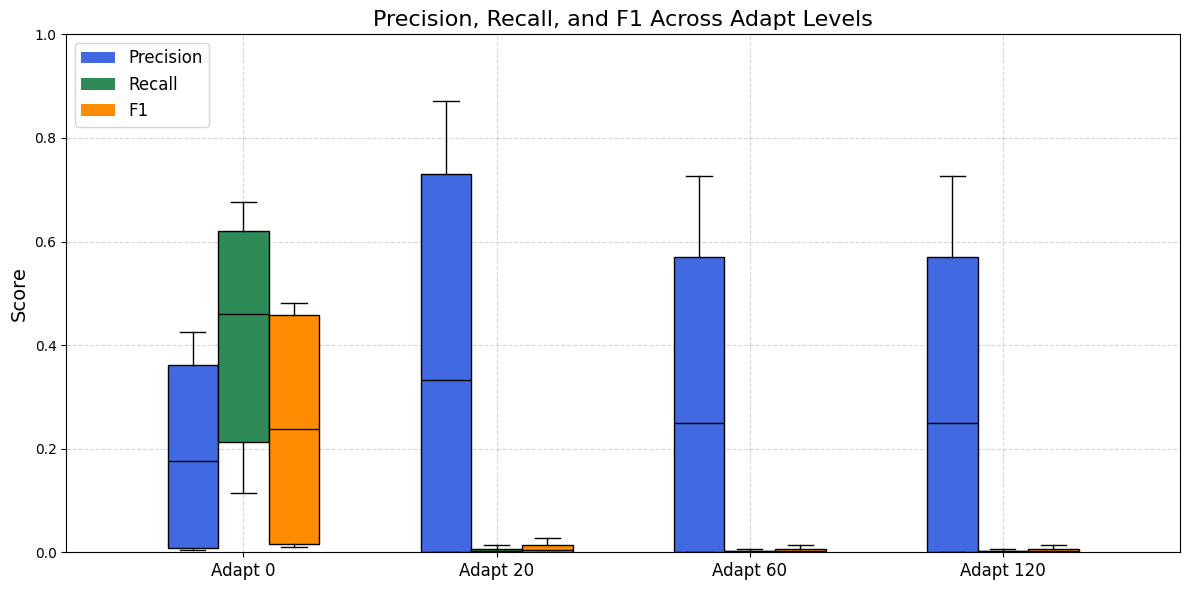

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Precision, Recall, and F1 Across Adapt Levels'}, ylabel='Score'>)

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

def plot_metrics_across_adapt(df, metrics=["precision", "recall", "f1"], colors=None):
    """
    Boxplot-like visualization of metrics across adapt levels.
    
    Args:
        df (pd.DataFrame): Must have columns ['adapt', 'network', 'dataset', ...metrics...]
        metrics (list): List of metrics to plot.
        colors (dict): Optional dict mapping metric -> color.
    """
    if colors is None:
        colors = {"precision": "royalblue", "recall": "seagreen", "f1": "darkorange"}

    adapt_levels = sorted(df['adapt'].unique())
    width = 0.2
    fig, ax = plt.subplots(figsize=(12,6))

    for i, metric in enumerate(metrics):
        metric_values = []
        positions = []
        for j, adapt in enumerate(adapt_levels):
            vals = df[df['adapt'] == adapt][metric].values
            pos = j + i*width - width  # slight shift for grouped bars
            positions.append(pos)
            metric_values.append(vals)

        # Draw boxplots for this metric
        for pos, vals in zip(positions, metric_values):
            bplot = ax.boxplot(vals, positions=[pos], widths=width, patch_artist=True,
                               showfliers=False, medianprops=dict(color='black'))
            for patch in bplot['boxes']:
                patch.set_facecolor(colors.get(metric, "gray"))

    # X-axis ticks
    ax.set_xticks(range(len(adapt_levels)))
    ax.set_xticklabels([f"Adapt {a}" for a in adapt_levels], fontsize=12)
    ax.set_ylabel("Score", fontsize=14)
    ax.set_title("Precision, Recall, and F1 Across Adapt Levels", fontsize=16)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.set_ylim(0,1)

    # Legend
    legend_handles = [Patch(facecolor=colors[m], label=m.capitalize()) for m in metrics]
    ax.legend(handles=legend_handles, fontsize=12, loc='upper left')

    plt.tight_layout()
    plt.show()
    return fig, ax


# --- Example usage ---
# df = pd.read_csv("metrics_summary.csv")
plot_metrics_across_adapt(df, metrics=["precision","recall","f1"])
